# PyTorch Model Visualization


In [3]:
import torch
import torch.nn as nn

In [4]:
num_features = 50
num_output = 3

# Define the model
model = nn.Sequential(
    nn.Linear(num_features, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, num_output),
)

### Model Inspection

To understand the architecture of a PyTorch model, we can inspect its parameters. The `model.parameters()` method returns an iterator over all the parameters (weights and biases) of the model. We can use this to count the total number of parameters, as well as how many of them are trainable (i.e., require gradients).


In [ ]:
# Generator object
print(model.parameters())

# Extracting the first parameter tensor from the generator object.
params = list(model.parameters())
param = params[0]
print(param)

# shapes: the shape of the parameter tensor,
print(f"param.shape: {param.shape}")

# numel: the total number of elements in the parameter tensor,
print(f"param.numel(): {param.numel()}")

# requires_grad: whether the parameter is trainable (i.e., whether it will be updated during training). You can set it to `False` if you want to freeze the parameter during training.
print(f"param.requires_grad: {param.requires_grad}")

<generator object Module.parameters at 0x00000267A7E38120>
Parameter containing:
tensor([[ 0.1238, -0.1082,  0.0412,  ..., -0.0904, -0.1308,  0.0594],
        [-0.0477,  0.0296, -0.1320,  ...,  0.0236, -0.0867,  0.1192],
        [-0.0426,  0.0498,  0.0394,  ...,  0.0679, -0.1301,  0.1375],
        ...,
        [ 0.0813, -0.0583,  0.0387,  ...,  0.0270, -0.0445, -0.1118],
        [-0.1155, -0.0365,  0.0637,  ...,  0.0155, -0.1186, -0.0208],
        [ 0.0840, -0.0210,  0.0668,  ..., -0.1046, -0.0221,  0.1024]],
       requires_grad=True)
param.shape: torch.Size([24, 50])
param.numel(): 1200
param.requires_grad: True


In [ ]:
# Generator object with names
print(model.named_parameters())

# Extracting the first named parameter from the generator object.
name_params = list(model.named_parameters())
name_param = name_params[0]
print(name_param)  # tuple of (name, param_tensor)

# name: the name of the parameter (e.g., "0.weight" for the weights of the first layer),
print(f"name: {name_param[0]}")

# param_tensor: the actual parameter tensor containing the weights or biases.
print(f"param_tensor: {name_param[1]}")
print(f"param_tensor.shape: {name_param[1].shape}")
print(f"param_tensor.numel(): {name_param[1].numel()}")
print(f"requires_grad: {name_param[1].requires_grad}")

<generator object Module.named_parameters at 0x00000267DA221B40>
('0.weight', Parameter containing:
tensor([[ 0.1238, -0.1082,  0.0412,  ..., -0.0904, -0.1308,  0.0594],
        [-0.0477,  0.0296, -0.1320,  ...,  0.0236, -0.0867,  0.1192],
        [-0.0426,  0.0498,  0.0394,  ...,  0.0679, -0.1301,  0.1375],
        ...,
        [ 0.0813, -0.0583,  0.0387,  ...,  0.0270, -0.0445, -0.1118],
        [-0.1155, -0.0365,  0.0637,  ...,  0.0155, -0.1186, -0.0208],
        [ 0.0840, -0.0210,  0.0668,  ..., -0.1046, -0.0221,  0.1024]],
       requires_grad=True))
name: 0.weight
param_tensor: Parameter containing:
tensor([[ 0.1238, -0.1082,  0.0412,  ..., -0.0904, -0.1308,  0.0594],
        [-0.0477,  0.0296, -0.1320,  ...,  0.0236, -0.0867,  0.1192],
        [-0.0426,  0.0498,  0.0394,  ...,  0.0679, -0.1301,  0.1375],
        ...,
        [ 0.0813, -0.0583,  0.0387,  ...,  0.0270, -0.0445, -0.1118],
        [-0.1155, -0.0365,  0.0637,  ...,  0.0155, -0.1186, -0.0208],
        [ 0.0840, -0.021

In [ ]:
def count_parameters(model):
    # Count total and trainable parameters in the model
    total_params = sum(p.numel() for p in model.parameters())
    # Count only trainable parameters (those that require gradients)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Print the results
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}\n")
    print("Parameters by layer:")

    # Print the number of parameters for each layer
    for name, param in model.named_parameters():
        print(f"\t{name}: {param.numel():,}")


count_parameters(model)

Total parameters: 1,623
Trainable parameters: 1,623

Parameters by layer:
	0.weight: 1,200
	0.bias: 24
	2.weight: 288
	2.bias: 12
	4.weight: 72
	4.bias: 6
	6.weight: 18
	6.bias: 3


### Torchsummary


In [24]:
from torchinfo import summary

input_size = (num_features,)
summary(model, input_size=input_size)

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [3]                       --
├─Linear: 1-1                            [24]                      1,224
├─ReLU: 1-2                              [24]                      --
├─Linear: 1-3                            [12]                      300
├─ReLU: 1-4                              [12]                      --
├─Linear: 1-5                            [6]                       78
├─ReLU: 1-6                              [6]                       --
├─Linear: 1-7                            [3]                       21
Total params: 1,623
Trainable params: 1,623
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

### Torchviz


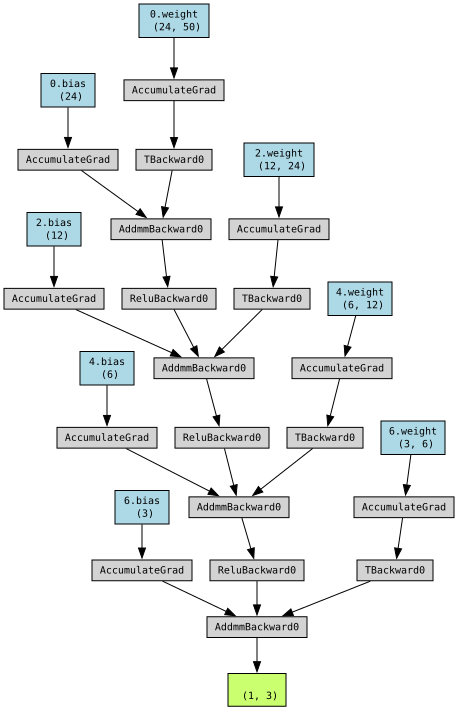

In [25]:
from torchviz import make_dot

X_sample = torch.rand(1, num_features)  # (batch_size, num_features)
Y_sample = model(X_sample)
make_dot(Y_sample, params=dict(model.named_parameters()))

### Tensorboard


- Type in your command prompt
  - `tensorboard --logdir=src/T01_basic_pytorch/runs`
- Visit http://localhost:6006


In [26]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("runs/model_visualization")
writer.add_graph(model, X_sample)
writer.close()

### App

- Visit https://netron.app/
- Load the saved model.


In [ ]:
torch.save(model, "./my_pytorch_model.pt")